# ML Homework 3 - Analytics Challenge: Individual Variable Data Exploration 
#### By Julia Reich on Oct 10, 2025

### Load Dataset to be Explored

In [5]:
import pandas as pd

# Load Analytics Challenge DFS Fraud data
dfs = pd.read_csv("DFS_Fraud_Data_Clean.csv")
print(dfs.shape)
dfs.head()

(863058, 60)


,Unnamed: 0,fraud_bool,income,name_email_similarity,salary,prev_address_months_count,current_address_months_count,customer_age,date_of_birth,days_since_request,...,bank_months_count_missing,has_other_cards_missing,proposed_credit_limit_missing,foreign_request_missing,source_missing,session_length_in_minutes_missing,device_os_missing,keep_alive_session_missing,device_distinct_emails_8w_missing,salary_missing
0,1,0,1.00,0.617426,105266.0,NaN,89.0,20-29,2004-10-18,0.010095,...,0,0,0,0,0,0,0,0,0,0
1,2,0,1.00,0.996707,122830.0,9.0,14.0,40-49,1982-01-01,0.012316,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0.75,0.475100,83960.0,11.0,14.0,30-39,1990-05-09,0.006991,...,0,0,0,0,0,0,0,0,0,0
3,4,0,1.00,0.842307,146723.0,NaN,29.0,40-49,1980-11-02,5.742626,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0.75,0.294840,89627.0,NaN,369.0,30-39,1987-06-03,0.024232,...,0,0,0,0,0,0,0,0,0,0


## Variable Reduction

### Business Logic

In [3]:
# View list of columns
dfs.columns

Index(['Unnamed: 0', 'fraud_bool', 'income', 'name_email_similarity', 'salary',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'date_of_birth', 'days_since_request',
       'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h',
       'velocity_24h', 'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month',
       'prev_address_months_count_missing',
       'current_address_months_count_missing', 'days_since_request_missing',
       'intended_balcon_amount_missing', 'payment_type_missing',
       'zip_count_4w_missing', 'velocity_6h_mis

In [6]:
# Remove Variables with Business Logic
# Here, we have a redundant ID variable. We also have age ranges as well as date of birth, which would be redundant.
#     We remove date of birth because we do not need the granularity of each birthday to inform our analysis;
#     the age ranges are enough and easier to work with.
dfs = dfs.drop(['Unnamed: 0',
               'date_of_birth'], axis=1)
dfs.head(3)

,fraud_bool,income,name_email_similarity,salary,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,...,bank_months_count_missing,has_other_cards_missing,proposed_credit_limit_missing,foreign_request_missing,source_missing,session_length_in_minutes_missing,device_os_missing,keep_alive_session_missing,device_distinct_emails_8w_missing,salary_missing
0,0,1.00,0.617426,105266.0,NaN,89.0,20-29,0.010095,NaN,AD,...,0,0,0,0,0,0,0,0,0,0
1,0,1.00,0.996707,122830.0,9.0,14.0,40-49,0.012316,NaN,AB,...,0,0,0,0,0,0,0,0,0,0
2,0,0.75,0.475100,83960.0,11.0,14.0,30-39,0.006991,NaN,AB,...,0,0,0,0,0,0,0,0,0,0


### Missingness

In [12]:
# Find how many missing values (if any) in each column of the DataFrame

missing_counts = dfs.isnull().sum()

missing_counts = missing_counts[missing_counts > 0]

missing_counts.sort_values(ascending=False)

current_address_months_count    3719
zip_count_4w                    3093
session_length_in_minutes       1756
device_distinct_emails_8w        313
proposed_credit_limit            174
velocity_24h                       4
credit_risk_score                  1
dtype: int64

In [ ]:
# Find columns with more than 50% of data missing
missing_counts = missing_counts[missing_counts > len(dfs)/2]

missing_counts.sort_values(ascending=False)

In [ ]:
# 2 columns have more than 50% of the data missing.
# Find how many missing values (% of all) in each.
missing_pct_intended_balcon_amount = round(dfs['intended_balcon_amount'].isna().sum()/len(dfs) * 100, 2)
missing_pct_prev_address_months_count = round(dfs['prev_address_months_count'].isna().sum()/len(dfs) * 100, 2)

print(f"Missing Percentage for intended_balcon_amount: {missing_pct_intended_balcon_amount}%")
print(f"Missing Percentage for prev_address_months_count: {missing_pct_prev_address_months_count}%")

In [7]:
# Imputing for more than 70% of missing values on a continuous variable clouds analytical clarity
#     and muddles interpretation.
# For this reason, I choose to remove the above two columns and their associated missingness flag columns.
dfs = dfs.drop(['intended_balcon_amount', 
                  'prev_address_months_count',
                  'intended_balcon_amount_missing',
                  'prev_address_months_count_missing'], axis=1)

# Check work
dfs.head(3)

,fraud_bool,income,name_email_similarity,salary,current_address_months_count,customer_age,days_since_request,payment_type,zip_count_4w,velocity_6h,...,bank_months_count_missing,has_other_cards_missing,proposed_credit_limit_missing,foreign_request_missing,source_missing,session_length_in_minutes_missing,device_os_missing,keep_alive_session_missing,device_distinct_emails_8w_missing,salary_missing
0,0,1.00,0.617426,105266.0,89.0,20-29,0.010095,AD,1658.0,9223,...,0,0,0,0,0,0,0,0,0,0
1,0,1.00,0.996707,122830.0,14.0,40-49,0.012316,AB,1095.0,4471,...,0,0,0,0,0,0,0,0,0,0
2,0,0.75,0.475100,83960.0,14.0,30-39,0.006991,AB,3483.0,14432,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# I notice my colleagues added many missing flag variable columns, so let's investigate
#     if the variables actually have missingness.
# See attached python notebook "Analytics Challenge Team 2 KC, CC, JR, YS" for more information on how
#     we created our missing flag variables.

# Select all columns whose names contain the string '_missing' to investigate, and 
#     create a new DataFrame for exploration.
dfs_missing_flags = dfs.filter(like='_missing')

# Check work
dfs_missing_flags.columns

In [ ]:
# Sum the values in each column
dfs_missing_flags.sum()

In [8]:
# Remove all variable flags with 0 missingness reported
dfs = dfs.drop(['days_since_request_missing',
    'payment_type_missing',
    'velocity_6h_missing',
    'velocity_4w_missing',
    'bank_branch_count_8w_missing',
    'date_of_birth_distinct_emails_4w_missing',
    'email_is_free_missing',
    'phone_home_valid_missing',
    'phone_mobile_valid_missing',
    'has_other_cards_missing',
    'foreign_request_missing',
    'source_missing',
    'device_os_missing',
    'keep_alive_session_missing',
    'salary_missing'], axis=1)

In [ ]:
# Check work

# Select all columns whose names contain the string '_missing' to investigate, and 
#     create a new DataFrame for exploration.
dfs_missing_flags = dfs.filter(like='_missing')

# Sum the values in each column
dfs_missing_flags.sum()

In [ ]:
# If I remove all missing values, the only column that would significantly diminish
#    the size of the dataset would be 'bank_months_count_missing', so I will investigate.

# get list of unique values for bank_months_count column
bank_months_count_unique_values = dfs['bank_months_count'].unique()
print(f"There are {len(bank_months_count_unique_values)} unique bank_months_count values: {bank_months_count_unique_values}")
print(f"Data Type: {dfs['bank_months_count'].dtype}.")

In [9]:
# Here, we see bank_months_count is a continuous float variable with a range 
#     from 1 to 30, with more than 200,000 missing values.
# I choose to remove the variable, because it represents "Age of applicant’s previous account (if held) in months."
#     This means we do not know if the missing values are from lack of data entry or from not having a previous account;
#     the variable is inherently nullable.
# Therefore, impution will not give an accurate picture of the data and will muddle the interpretations of the data,
#     and I will remove the variable along with the associated missing flag variable.

dfs = dfs.drop(['bank_months_count',
               'bank_months_count_missing'], axis=1)

In [ ]:
# Check work

# Select all columns whose names contain the string '_missing' to investigate, and 
#     create a new DataFrame for exploration.
dfs_missing_flags = dfs.filter(like='_missing')

# Sum the values in each column
dfs_missing_flags.sum()

In [10]:
# With the remaining variables, it is safe to drop remaining rows with null values.
# If we impute with the median, the missingness will have too low a variability to be useful in analysis.

# Drop all rows with any null values
dfs_no_missings = dfs.dropna()

# Check work
print(f"Original shape: {dfs.shape}, None Missing Shape: {dfs_no_missings.shape}")

# We still have more than enough data to work with here!
dfs = dfs_no_missings

Original shape: (863058, 60), None Missing Shape: (55693, 60)


### Low Variability

In [9]:
from sklearn.feature_selection import VarianceThreshold

dfs_num = dfs.select_dtypes(include=['number'])

# Set variance threshold; 0.01 is a common starting point
threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit(dfs_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = dfs_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['device_fraud_count', 'current_address_months_count_missing', 'days_since_request_missing', 'payment_type_missing', 'zip_count_4w_missing', 'velocity_6h_missing', 'velocity_24h_missing', 'velocity_4w_missing', 'bank_branch_count_8w_missing', 'date_of_birth_distinct_emails_4w_missing', 'credit_risk_score_missing', 'email_is_free_missing', 'phone_home_valid_missing', 'phone_mobile_valid_missing', 'has_other_cards_missing', 'proposed_credit_limit_missing', 'foreign_request_missing', 'source_missing', 'session_length_in_minutes_missing', 'device_os_missing', 'keep_alive_session_missing', 'device_distinct_emails_8w_missing', 'salary_missing']


In [ ]:
# The only variable we should investigate is device_fraud_count; the rest are missing variable flags
#     for columns in which null values were removed; we expect them to have low variance and we will remove them.
device_fraud_count_unique_values = dfs['device_fraud_count'].unique()
print(f"There are {len(device_fraud_count_unique_values)} unique device_fraud_count values: {device_fraud_count_unique_values}")

In [ ]:
# Loop through only categorical variables('object') and look at top category % 

for col in dfs.select_dtypes(include='object'):

    # col is each categorical variable in dataset. 
    top_freq = dfs[col].value_counts(normalize=True).iloc[0]
    
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [10]:
# Remove the variables with low variability
dfs = dfs.drop(['device_fraud_count', 
                'source',
                'current_address_months_count_missing', 
                'zip_count_4w_missing', 
                'velocity_24h_missing', 
                'credit_risk_score_missing', 
                'proposed_credit_limit_missing', 
                'session_length_in_minutes_missing', 
                'device_distinct_emails_8w_missing'], axis=1)

## View the dataframe after variable reduction

In [11]:
print(dfs.shape)
dfs.head()

(863058, 28)


,fraud_bool,income,name_email_similarity,salary,current_address_months_count,customer_age,days_since_request,payment_type,zip_count_4w,velocity_6h,...,phone_home_valid,phone_mobile_valid,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,month
0,0,1.00,0.617426,105266.0,89.0,20-29,0.010095,AD,1658.0,9223,...,1.0,1.0,0.0,1500.0,0.0,3.363854,other,1.0,1.0,0
1,0,1.00,0.996707,122830.0,14.0,40-49,0.012316,AB,1095.0,4471,...,0.0,1.0,0.0,200.0,0.0,22.730559,windows,0.0,1.0,0
2,0,0.75,0.475100,83960.0,14.0,30-39,0.006991,AB,3483.0,14432,...,0.0,1.0,0.0,200.0,0.0,15.215816,linux,1.0,1.0,0
3,0,1.00,0.842307,146723.0,29.0,40-49,5.742626,AA,2339.0,7602,...,1.0,1.0,0.0,200.0,0.0,3.743048,other,0.0,1.0,0
4,0,0.75,0.294840,89627.0,369.0,30-39,0.024232,AD,1204.0,11557,...,1.0,1.0,0.0,200.0,0.0,6.987316,linux,1.0,1.0,0


In [ ]:
print(dfs.columns)

## Feature Engineering
In the data cleaning step, before exploring the data, there were a few features that were engineered:
   - `customer_age`: Binned in decade groups: [10, 19), [20, 29) ... (90 - 100].  
   - `month`: designated Jan-Aug as 0-7, respectively.
See 'HW_2_Automatic_Variable_Reduction.ipynb' file for details.

In the Univariate Statistical Testing section below, Python will make dummy features for the following variables:
   - `payment_type`
   - `employment_status`  
   - `housing_status`
   - `device_os`

## Univariate Statistical Testing

In [14]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dfs, test_size = 0.25, random_state = 1234)

In [15]:
import statsmodels.api as sm

# Dummy code the Categorical Variables
predictors = train.drop(columns=['fraud_bool'])
predictors = pd.get_dummies(predictors, drop_first=True)  # python ignores numerical variables. Remove first category for baseline comparison
predictors = predictors.astype(float)  # make sure everything is stored as a numerical value

# Create Predictor and Target Objects
X = predictors
y = train['fraud_bool']

In [16]:
# Run simple linear regressions with fraud_bool as target variable and one of each predictor variable separately.
from sklearn.feature_selection import SelectKBest, f_regression

# Fit SelectKBest
selector = SelectKBest(score_func=f_regression, k='all')  # 'all' keeps all features for scoring
selector.fit(X, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Sort by F-score descending
scores_df = scores_df.sort_values(by='F_score', ascending=False)

with pd.option_context('display.max_rows', None):
    print(scores_df)

# Each output row below is one simple linear regression
# F_score = (t-test statistic)^2

                             Feature      F_score        p_value
48                 device_os_windows  3889.819910   0.000000e+00
11                 credit_risk_score  3168.983073   0.000000e+00
16             proposed_credit_limit  2947.022419   0.000000e+00
19                keep_alive_session  1626.170324   0.000000e+00
2                             salary  1383.978545  1.344441e-302
10  date_of_birth_distinct_emails_4w  1174.358791  3.905975e-257
0                             income  1163.070877  1.097730e-254
26                customer_age_60-69   998.074427  6.946983e-219
1              name_email_similarity   890.200247  1.805744e-195
20         device_distinct_emails_8w   859.003906  1.069889e-188
41                 housing_status_BC   835.400069  1.425955e-183
15                   has_other_cards   801.195969  3.810672e-176
13                  phone_home_valid   792.970624  2.328765e-174
47                   device_os_other   785.343541  1.055307e-172
25                custome

## Exploratory Tests for Individual Variables

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

count    854229.000000
mean          0.011002
std           0.104311
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: fraud_bool, dtype: float64


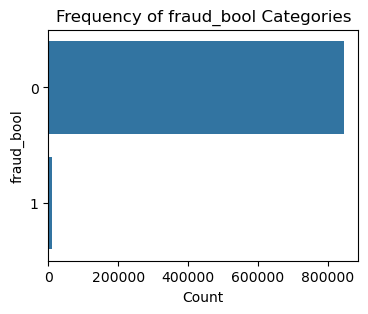

count     854229
unique         9
top        30-39
freq      265900
Name: customer_age, dtype: object


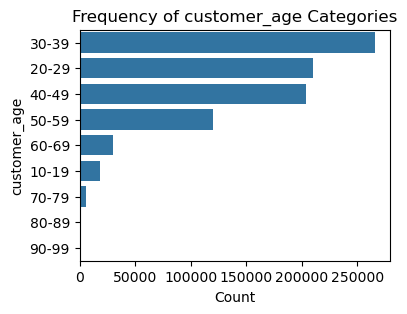

count     854229
unique         5
top           AB
freq      316535
Name: payment_type, dtype: object


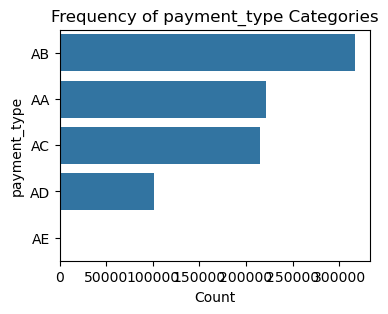

count     854229
unique         7
top           CA
freq      623748
Name: employment_status, dtype: object


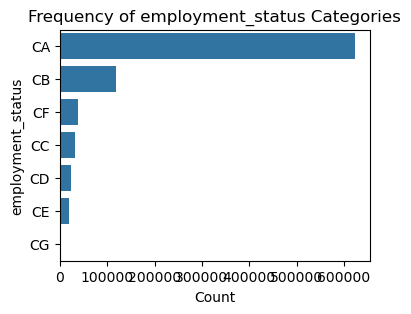

count    854229.000000
mean          0.529414
std           0.499134
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: email_is_free, dtype: float64


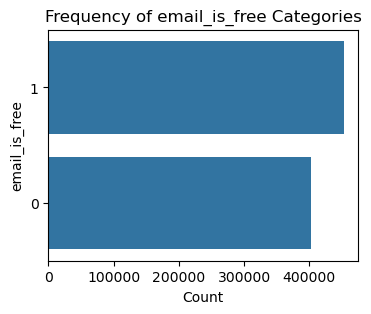

count    854229.000000
mean          0.577439
std           0.493967
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: keep_alive_session, dtype: float64


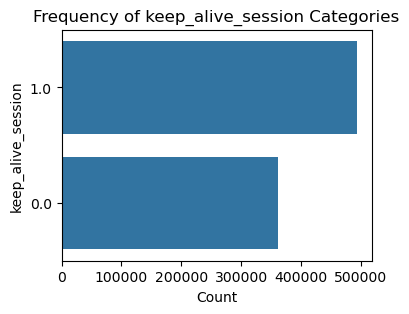

count     854229
unique         7
top           BC
freq      316552
Name: housing_status, dtype: object


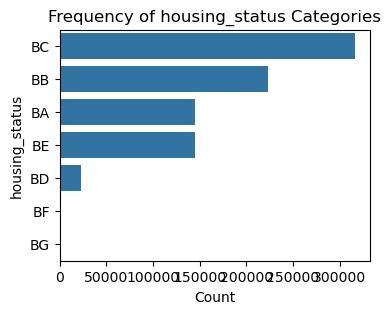

count    854229.000000
mean          3.532955
std           2.375555
min           0.000000
25%           1.000000
50%           4.000000
75%           6.000000
max           7.000000
Name: month, dtype: float64


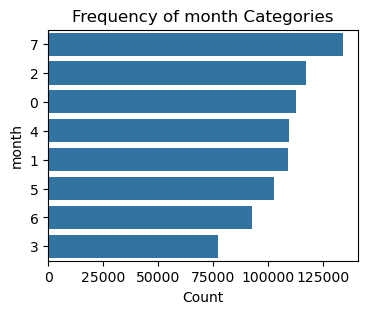

In [18]:
# Categorical Variables visualizations
cat_vars = dfs[['fraud_bool','customer_age','payment_type','employment_status','email_is_free','keep_alive_session',
                'housing_status','month']]

for col in cat_vars:
    print(dfs[col].describe())
    
    plt.figure(figsize=(4, 3))
    sns.countplot(y=dfs[col], order=dfs[col].value_counts().index)
    plt.title(f'Frequency of {col} Categories')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

count    863058.000000
mean          0.681467
std           0.294606
min           0.250000
25%           0.500000
50%           0.750000
75%           1.000000
max           1.000000
Name: income, dtype: float64


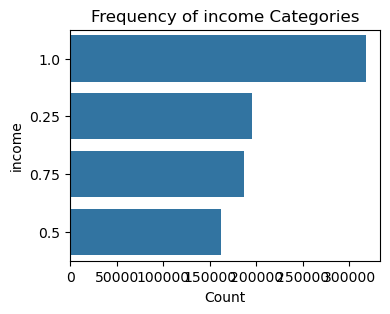

count    863058.000000
mean          0.222968
std           0.416237
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: has_other_cards, dtype: float64


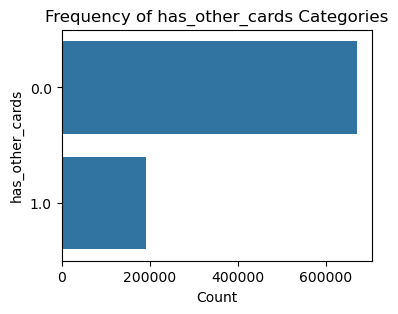

count    863058.000000
mean          0.417349
std           0.493122
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: phone_home_valid, dtype: float64


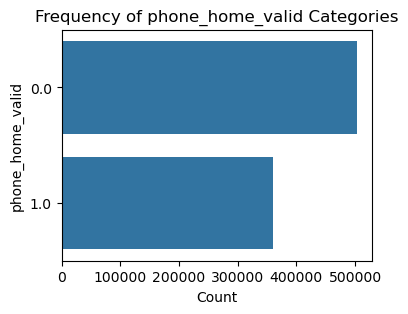

count    863058.000000
mean          0.889613
std           0.313371
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: phone_mobile_valid, dtype: float64


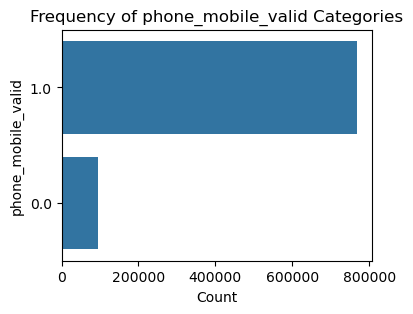

count    863058.000000
mean          0.025209
std           0.156760
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: foreign_request, dtype: float64


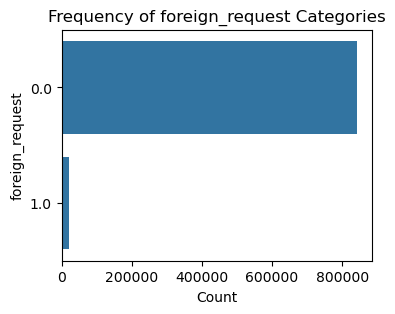

count     863058
unique         5
top        other
freq      296046
Name: device_os, dtype: object


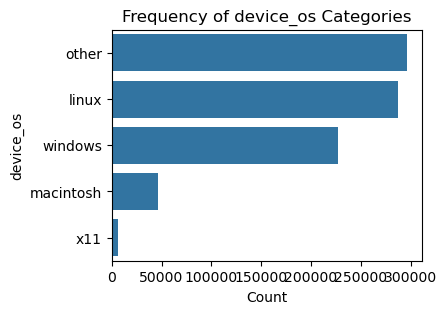

In [4]:
# Categorical Variables visualizations
cat_vars_2 = dfs[['income','has_other_cards','phone_home_valid','phone_mobile_valid','foreign_request','device_os']]

for col in cat_vars_2:
    print(dfs[col].describe())
    
    plt.figure(figsize=(4, 3))
    sns.countplot(y=dfs[col], order=dfs[col].value_counts().index)
    plt.title(f'Frequency of {col} Categories')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

count    854229.000000
mean          0.681713
std           0.294559
min           0.250000
25%           0.500000
50%           0.750000
75%           1.000000
max           1.000000
Name: income, dtype: float64


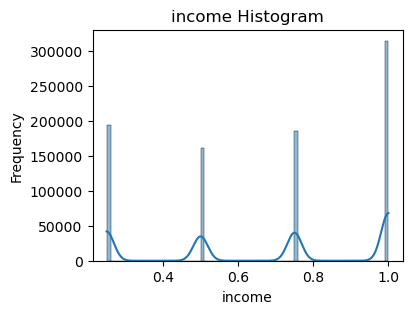

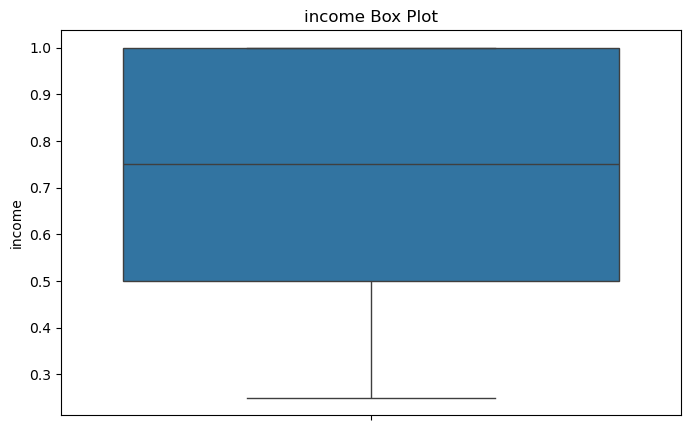

count    854229.000000
mean      84032.997553
std       42687.457344
min       15000.000000
25%       42556.000000
50%       92669.000000
75%      121782.000000
max      150852.000000
Name: salary, dtype: float64


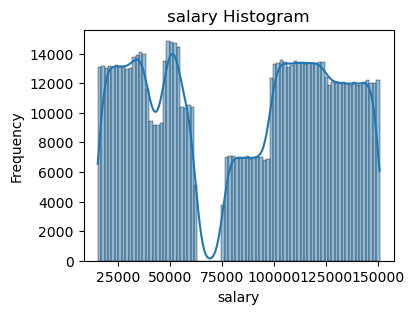

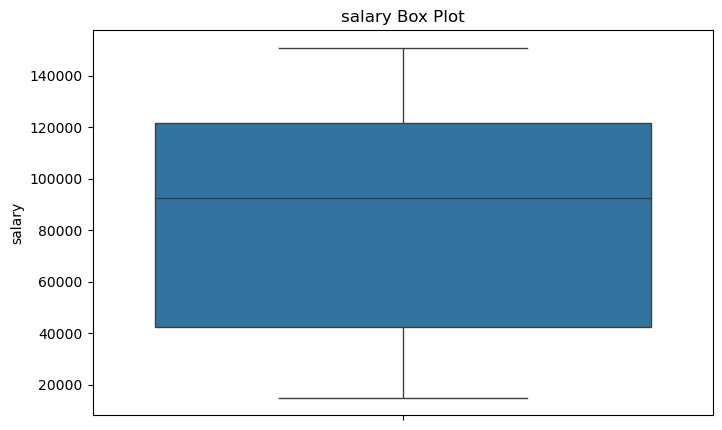

count    854229.000000
mean        131.102745
std          69.687225
min        -170.000000
25%          83.000000
50%         122.000000
75%         178.000000
max         386.000000
Name: credit_risk_score, dtype: float64


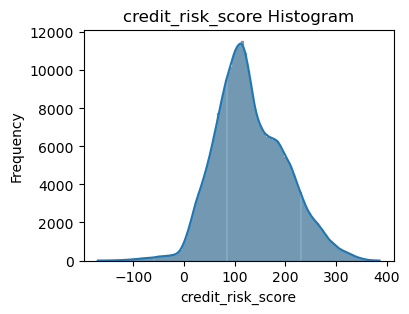

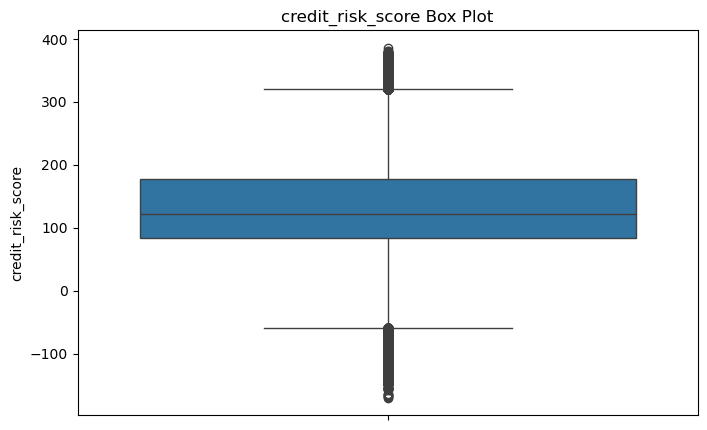

count    854229.000000
mean        516.611096
std         487.890964
min         200.000000
25%         200.000000
50%         200.000000
75%         500.000000
max        2000.000000
Name: proposed_credit_limit, dtype: float64


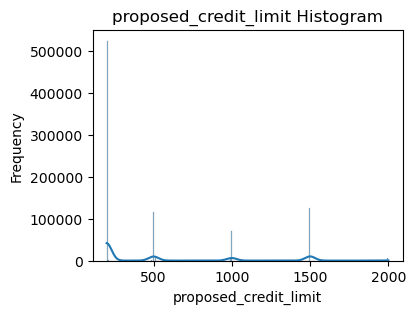

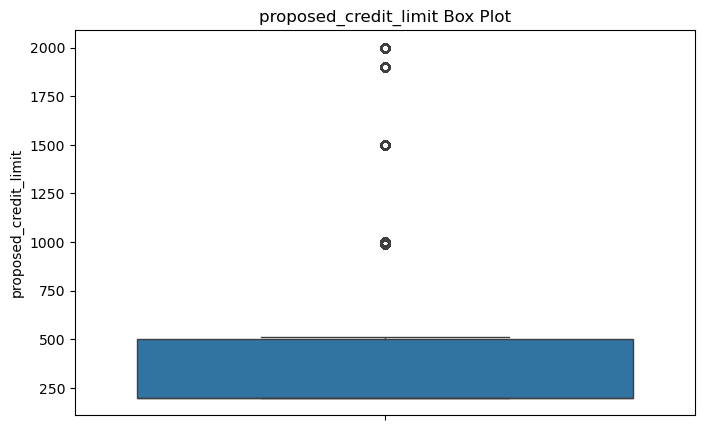

count    854229.000000
mean          7.555330
std           8.024970
min           0.000872
25%           3.116589
50%           5.119800
75%           8.866314
max          83.376775
Name: session_length_in_minutes, dtype: float64


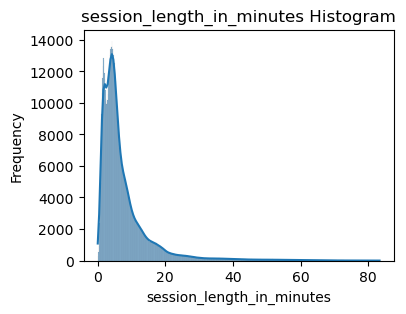

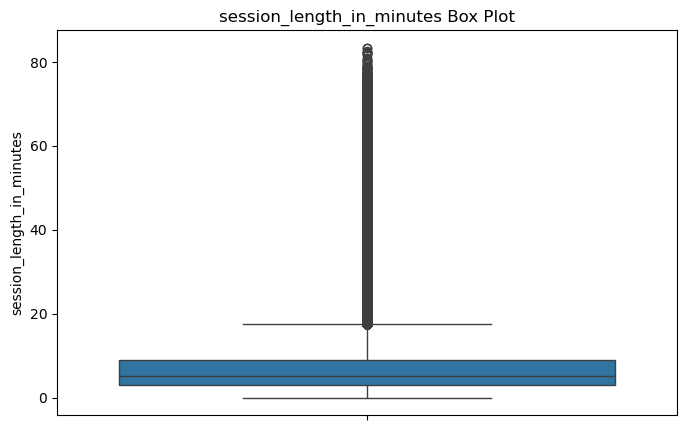

count    854229.000000
mean          0.494048
std           0.289079
min           0.000001
25%           0.225597
50%           0.492696
75%           0.755859
max           0.999999
Name: name_email_similarity, dtype: float64


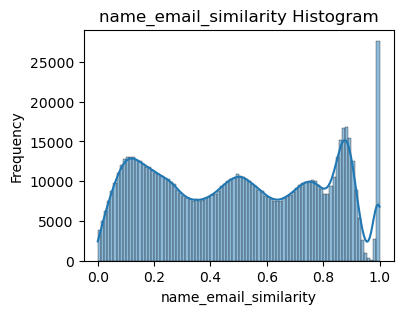

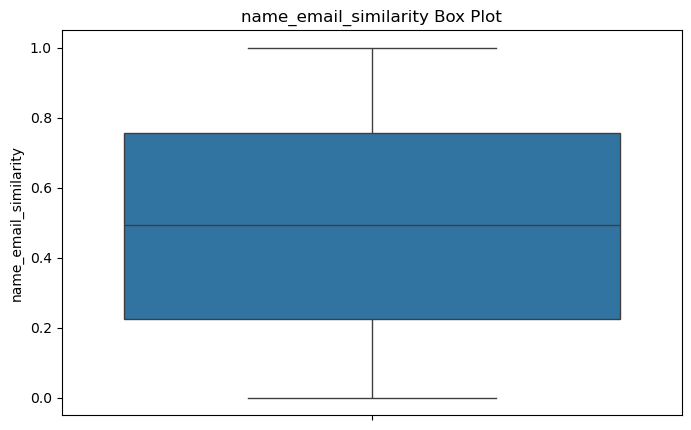

count    854229.000000
mean          9.498778
std           5.030796
min           0.000000
25%           6.000000
50%           9.000000
75%          13.000000
max          39.000000
Name: date_of_birth_distinct_emails_4w, dtype: float64


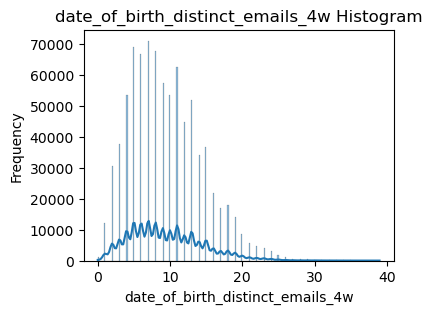

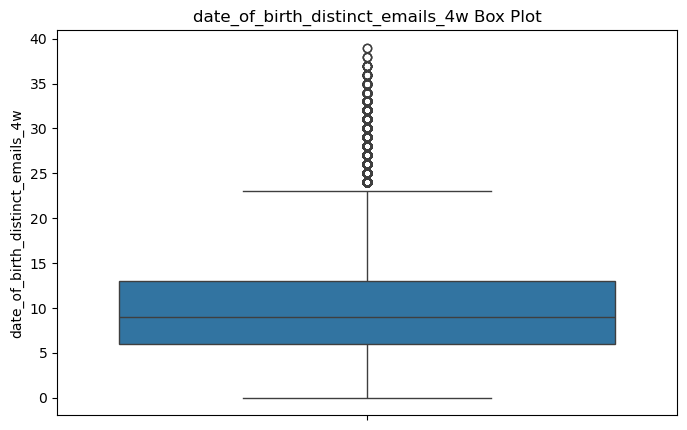

count    854229.000000
mean          1.020229
std           0.173285
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: device_distinct_emails_8w, dtype: float64


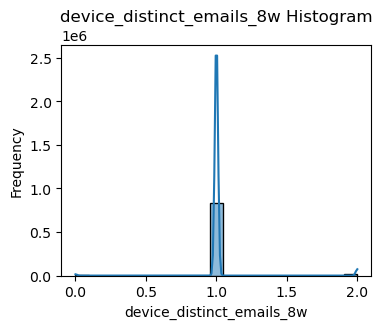

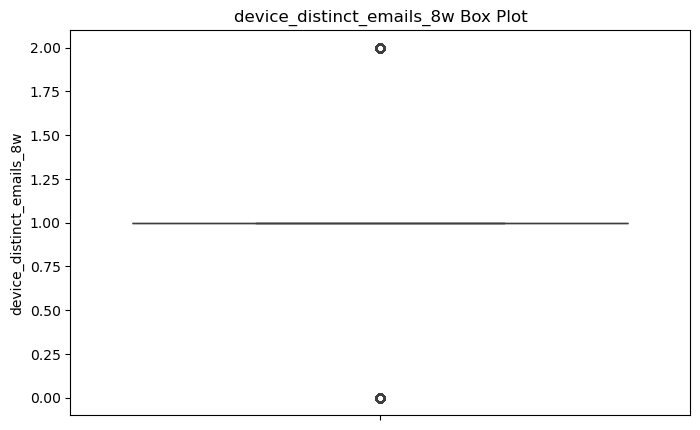

In [20]:
# Numeric Variables visualizations
numeric_vars = dfs[['salary','credit_risk_score','proposed_credit_limit', 'session_length_in_minutes',
                    'name_email_similarity', 'date_of_birth_distinct_emails_4w', 'device_distinct_emails_8w']]

for col in numeric_vars: 
    # In Numbers
    print(dfs[col].describe())
    
    # Histogram
    plt.figure(figsize=(4,3))
    sns.histplot(dfs[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
    # Box Plot
    plt.figure(figsize=(4,3))
    sns.boxplot(y=dfs[col])
    plt.title(f'{col} Box Plot')
    plt.ylabel(col)
    plt.show()

count    854229.000000
mean         86.911497
std          88.377165
min           0.000000
25%          20.000000
50%          53.000000
75%         130.000000
max         406.000000
Name: current_address_months_count, dtype: float64


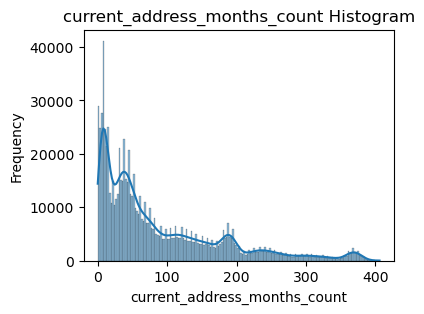

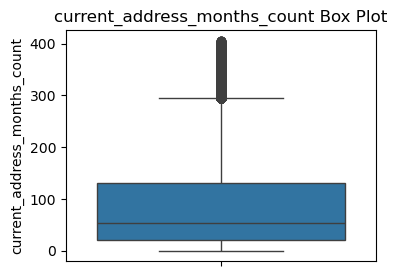

count    8.542290e+05
mean     1.017671e+00
std      5.356805e+00
min      4.036860e-09
25%      7.189592e-03
50%      1.516233e-02
75%      2.628252e-02
max      7.658148e+01
Name: days_since_request, dtype: float64


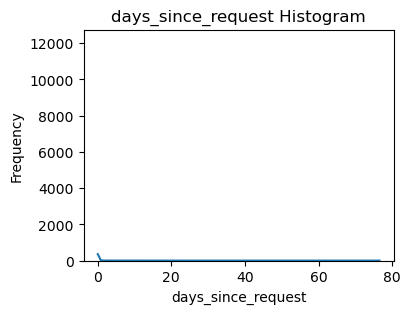

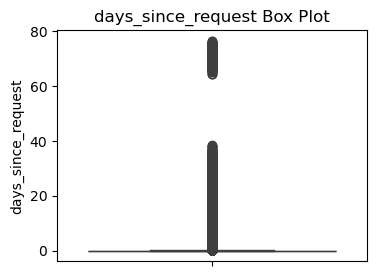

count    854229.000000
mean        184.993186
std         460.445156
min           0.000000
25%           1.000000
50%           9.000000
75%          25.000000
max        2385.000000
Name: bank_branch_count_8w, dtype: float64


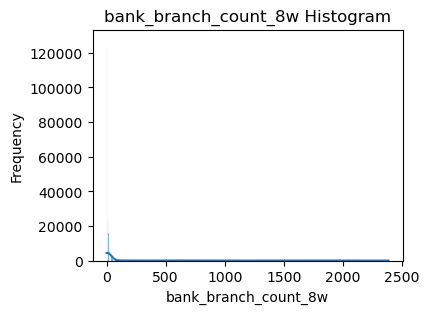

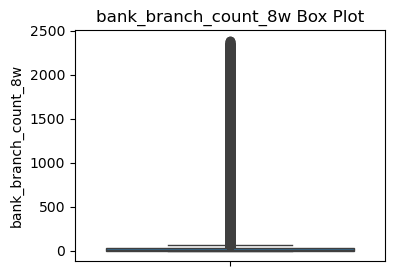

count    854229.000000
mean       1566.052197
std         990.531578
min           1.000000
25%         894.000000
50%        1262.000000
75%        1939.000000
max        5767.000000
Name: zip_count_4w, dtype: float64


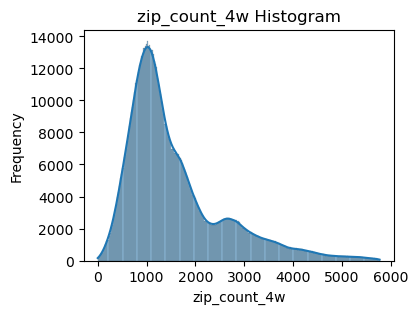

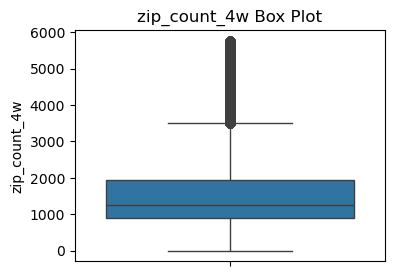

count    854229.000000
mean       5663.752185
std        3009.314851
min        -171.000000
25%        3435.000000
50%        5318.000000
75%        7678.000000
max       16716.000000
Name: velocity_6h, dtype: float64


In [ ]:
# Numeric Variables visualizations
numeric_vars_2 = dfs[['current_address_months_count', 'bank_branch_count_8w',
                    'zip_count_4w', 'velocity_6h', 'velocity_4w', 'velocity_24h']]
#'salary',
for col in numeric_vars_2: 
    # In Numbers
    print(dfs[col].describe())
    
    # Histogram
    plt.figure(figsize=(4, 3))
    sns.histplot(dfs[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
    # Box Plot
    plt.figure(figsize=(4, 3))
    sns.boxplot(y=dfs[col])
    plt.title(f'{col} Box Plot')
    plt.ylabel(col)
    plt.show()